In [3]:
import sys
import os
import logging
from pathlib import Path

import numpy as np
import pandas as pd

# ── Setup project path ──────────────────────────────────────────────────────
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    ALL_RAW_FILES, REPORTS_DIR, FIGURES_DIR, TABLES_DIR, DATA_PROCESSED,
    print_file_status, ensure_dirs,
)
from src.data_loading import (
    load_players, load_games, load_career_successes,
    load_combine_results, load_combine_tracking, load_player_play,
    quick_schema,
)
from src.player_mapping import validate_player_joins, print_join_report, validate_combine_tracking
from src.visualization import plot_missing_data_heatmap

# ── Configure logging ───────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(levelname)s | %(name)s | %(message)s',
)
log = logging.getLogger('01_data_inventory')

# ── Create output directories ───────────────────────────────────────────────
ensure_dirs()

print('Project root:', PROJECT_ROOT)
print('Python version:', sys.version)
print('Pandas version:', pd.__version__)
print('NumPy version:', np.__version__)
print()
print_file_status()

Project root: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027
Python version: 3.11.5 (tags/v3.11.5:cce6ba9, Aug 24 2023, 14:38:34) [MSC v.1936 64 bit (AMD64)]
Pandas version: 3.0.6
NumPy version: 2.4.6

File                           Status             Size
-------------------------------------------------------
players                        ✓ FOUND           0.0 MB
combine_results                ✓ FOUND           0.0 MB
combine_tracking               ✓ FOUND          79.9 MB
player_career_successes        ✓ FOUND           0.0 MB
player_play                    ✓ FOUND         140.1 MB
games                          ✓ FOUND           0.0 MB
game_tracking_2023             ✓ FOUND         319.9 MB
game_tracking_2024             ✓ FOUND         684.7 MB
game_tracking_2025             ✓ FOUND         975.2 MB


# 01 — Data Inventory

**Purpose**: Inspect every dataset file — schema, row counts, memory usage, missing values, categorical distributions, and join integrity.

**Output**: `outputs/reports/data_inventory.md`

> **Rule**: Do NOT fabricate results. Every number in this notebook comes from the actual data.
> If a file is missing, the notebook will report it clearly rather than failing silently.

## 1. Quick Schema Peek

Before loading full files, inspect column names and sample values from each file.

In [4]:
schemas = {}

for name, path in ALL_RAW_FILES.items():
    if not path.exists():
        print(f'✗ {name}: FILE NOT FOUND — {path}')
        continue
    head, dtypes = quick_schema(path, n_rows=3)
    schemas[name] = dtypes
    print('\n' + '='*60)
    print(f'  {name}  ({path.stat().st_size / 1_048_576:.1f} MB)')
    print(f'  Columns ({len(head.columns)}):')
    display(dtypes)
    print(f'  Head:')
    display(head)


  players  (0.0 MB)
  Columns (10):


,column,dtype,sample_value
0,nfl_id,int64,55867
1,display_name,str,Will Anderson
2,draft_year,int64,2023
3,nfl_position,str,DE
4,birth_date,str,2001-09-02
5,college_name,str,Alabama
6,college_conference,str,Southeastern Conference
7,draft_round,int64,1
8,draft_pick_within_round,int64,3
9,draft_overall_pick,int64,3


  Head:


,nfl_id,display_name,draft_year,nfl_position,birth_date,college_name,college_conference,draft_round,draft_pick_within_round,draft_overall_pick
0,55867,Will Anderson,2023,DE,2001-09-02,Alabama,Southeastern Conference,1,3,3
1,55870,Paris Johnson,2023,T,2001-07-31,Ohio State,Big Ten Conference,1,6,6
2,55874,Darnell Wright,2023,T,2001-08-10,Tennessee,Southeastern Conference,1,10,10



  combine_results  (0.0 MB)
  Columns (18):


...

,game_id,play_id,nfl_id,time,x,y,s,a,dis,o,dir,event
0,2024080952,3379,57367,2024-08-10T01:30:31.800,87.09,22.52,0.28,0.11,0.03,98.51,126.08,NaN
1,2024080952,3379,57367,2024-08-10T01:30:31.900,87.11,22.51,0.24,0.18,0.02,97.33,125.81,NaN
2,2024080952,3379,57367,2024-08-10T01:30:32.000,87.12,22.50,0.17,0.24,0.01,96.65,124.99,NaN



  game_tracking_2025  (975.2 MB)
  Columns (12):


,column,dtype,sample_value
0,game_id,int64,2025090701
1,play_id,int64,290
2,nfl_id,int64,57347
3,time,str,2025-09-07T17:09:39.500
4,x,float64,83.06
5,y,float64,32.06
6,s,float64,0.1
7,a,float64,0.06
8,dis,float64,0.04
9,o,float64,8.0


  Head:


,game_id,play_id,nfl_id,time,x,y,s,a,dis,o,dir,event
0,2025090701,290,57347,2025-09-07T17:09:39.500,83.06,32.06,0.10,0.06,0.04,8.00,18.86,NaN
1,2025090701,290,57347,2025-09-07T17:09:39.600,83.07,32.07,0.10,0.07,0.02,2.61,21.95,NaN
2,2025090701,290,57347,2025-09-07T17:09:39.700,83.06,32.06,0.07,0.05,0.02,357.42,16.24,NaN


## 2. Load Small Files Fully

In [5]:
# Load all small files
players = None
games = None
career_successes = None
combine_results = None

try:
    players = load_players()
    print(f'players: {len(players):,} rows × {players.shape[1]} cols')
    print(players.dtypes.to_string())
except FileNotFoundError as e:
    print(f'ERROR: {e}')

try:
    games = load_games()
    print(f'\ngames: {len(games):,} rows × {games.shape[1]} cols')
    display(games.head(3))
except FileNotFoundError as e:
    print(f'ERROR: {e}')

try:
    career_successes = load_career_successes()
    print(f'\ncareer_successes: {len(career_successes):,} rows × {career_successes.shape[1]} cols')
except FileNotFoundError as e:
    print(f'ERROR: {e}')

try:
    combine_results = load_combine_results(cols=None)  # Load ALL columns to see what's there
    print(f'\ncombine_results: {len(combine_results):,} rows × {combine_results.shape[1]} cols')
    display(combine_results.head(3))
except FileNotFoundError as e:
    print(f'ERROR: {e}')

INFO | src.data_loading | Loaded players: 510 rows × 10 cols | 0.1 MB | source: players.csv
WARNING | src.data_loading | players — columns with missing values:
draft_round                127
draft_pick_within_round    127
draft_overall_pick         127
INFO | src.data_loading | Loaded games: 1,002 rows × 7 cols | 0.1 MB | source: games.csv
INFO | src.data_loading | games — no missing values detected.


players: 510 rows × 10 cols
nfl_id                       int64
display_name                   str
draft_year                   int64
nfl_position                   str
birth_date                     str
college_name                   str
college_conference             str
draft_round                float64
draft_pick_within_round    float64
draft_overall_pick         float64

games: 1,002 rows × 7 cols


,game_id,game_key,season,season_type,week,home_team_abbr,visitor_team_abbr
0,2023090700,59173,2023,REG,1,KC,DET
1,2023091000,59174,2023,REG,1,ATL,CAR
2,2023091001,59175,2023,REG,1,BAL,HOU


INFO | src.data_loading | Loaded career_successes: 510 rows × 9 cols | 0.0 MB | source: player_career_successes.csv
INFO | src.data_loading | career_successes — no missing values detected.
WARNING | src.data_loading | combine_results: requested columns not in file (skipped): ['position']
INFO | src.data_loading | Loaded combine_results: 510 rows × 11 cols | 0.0 MB | source: combine_results.csv
WARNING | src.data_loading | combine_results — columns with missing values:
ten_yd_split                     85
forty                            86
vertical                         72
broad_jump                       87
three_cone                      330
short_shuttle                   309
bench_reps                      318
ngs_college_production_score      1
ngs_final_score                   1



career_successes: 510 rows × 9 cols

combine_results: 510 rows × 11 cols


,nfl_id,ten_yd_split,forty,vertical,broad_jump,three_cone,short_shuttle,bench_reps,ngs_athleticism_score,ngs_college_production_score,ngs_final_score
0,56040,1.60,4.84,38.5,125.0,NaN,NaN,NaN,60,NaN,NaN
1,56010,1.58,4.59,33.5,116.0,NaN,NaN,23.0,60,77.0,74.0
2,56085,1.57,4.55,40.0,128.0,6.87,4.12,23.0,97,65.0,79.0


## 3. Players — Detailed Profile

In [6]:
if players is not None:
    print('=== PLAYERS TABLE ===')
    print(f'Shape: {players.shape}')
    print(f'\nUnique nfl_id: {players["nfl_id"].nunique()}')
    print(f'Null nfl_id: {players["nfl_id"].isna().sum()}')
    print(f'nfl_id unique? {players["nfl_id"].is_unique}')
    print()

    # Missing values
    miss = players.isnull().sum()
    miss = miss[miss > 0]
    if not miss.empty:
        print('Columns with missing values:')
        print((miss / len(players) * 100).to_string())
    else:
        print('No missing values in players.')

    print()

    # Position distribution
    if 'position' in players.columns:
        print('Position value counts:')
        display(players['position'].value_counts().to_frame())

    # Numeric summary
    print('\nNumeric summary:')
    display(players.describe())

=== PLAYERS TABLE ===
Shape: (510, 10)

Unique nfl_id: 510
Null nfl_id: 0
nfl_id unique? True

Columns with missing values:
draft_round                24.901961
draft_pick_within_round    24.901961
draft_overall_pick         24.901961


Numeric summary:


,nfl_id,draft_year,draft_round,draft_pick_within_round,draft_overall_pick
count,510.000000,510.000000,383.000000,383.000000,383.000000
mean,57331.319608,2024.025490,4.101828,19.475196,126.535248
std,979.506689,0.808439,1.913734,11.184497,72.197252
min,55867.000000,2023.000000,1.000000,1.000000,3.000000
25%,56273.500000,2023.000000,2.000000,10.000000,63.500000
50%,57290.000000,2024.000000,4.000000,20.000000,122.000000
75%,58302.750000,2025.000000,6.000000,28.500000,186.000000
max,59278.000000,2025.000000,7.000000,43.000000,257.000000


## 4. Combine Results — Detailed Profile

=== COMBINE RESULTS ===
Shape: (510, 11)
Columns: ['nfl_id', 'ten_yd_split', 'forty', 'vertical', 'broad_jump', 'three_cone', 'short_shuttle', 'bench_reps', 'ngs_athleticism_score', 'ngs_college_production_score', 'ngs_final_score']

Missing values (%):


,missing_pct
three_cone,64.705882
bench_reps,62.352941
short_shuttle,60.588235
broad_jump,17.058824
forty,16.862745
ten_yd_split,16.666667
vertical,14.117647
ngs_final_score,0.196078
ngs_college_production_score,0.196078



Numeric summary:


,nfl_id,ten_yd_split,forty,vertical,broad_jump,three_cone,short_shuttle,bench_reps,ngs_athleticism_score,ngs_college_production_score,ngs_final_score
count,510.000000,425.000000,424.000000,438.000000,423.000000,180.000000,201.000000,192.000000,510.000000,509.000000,509.000000
mean,57331.319608,1.632000,4.733514,33.810502,118.151300,7.310611,4.466318,21.718750,72.454902,67.475442,70.333988
std,979.506689,0.115573,0.309449,4.141179,9.064842,0.390453,0.254316,5.718901,10.612339,8.317156,7.530414
min,55867.000000,1.460000,4.280000,23.000000,93.000000,6.570000,3.930000,8.000000,51.000000,50.000000,52.000000
25%,56273.500000,1.540000,4.470000,31.000000,111.000000,6.997500,4.280000,17.000000,65.000000,61.000000,65.000000
50%,57290.000000,1.590000,4.620000,34.000000,120.000000,7.290000,4.450000,22.000000,73.000000,66.000000,70.000000
75%,58302.750000,1.740000,5.010000,37.000000,125.000000,7.622500,4.680000,26.000000,80.000000,73.000000,75.000000
max,59278.000000,1.960000,5.480000,44.000000,138.000000,8.190000,5.030000,39.000000,99.000000,99.000000,94.000000


INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\missing_combine_results.png


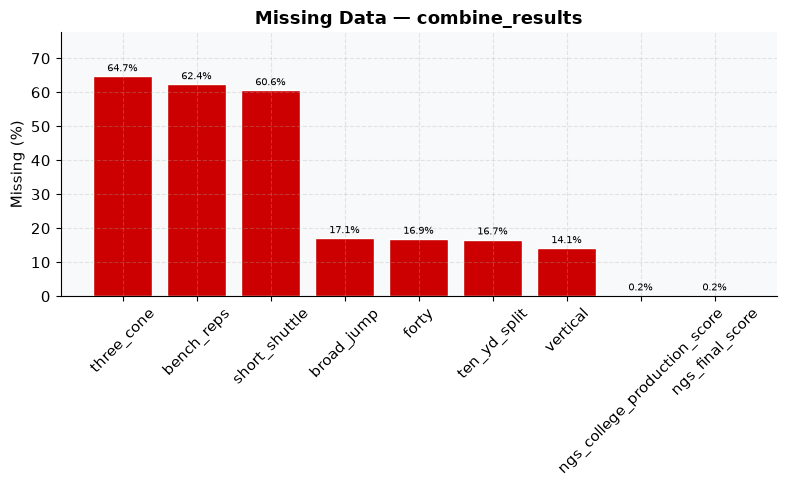

In [7]:
if combine_results is not None:
    print('=== COMBINE RESULTS ===')
    print(f'Shape: {combine_results.shape}')
    print(f'Columns: {combine_results.columns.tolist()}')
    print()

    # Missing values per column (as percentage)
    miss_pct = (combine_results.isnull().sum() / len(combine_results) * 100).sort_values(ascending=False)
    miss_pct = miss_pct[miss_pct > 0]
    print('Missing values (%):')
    display(miss_pct.to_frame('missing_pct'))

    print('\nNumeric summary:')
    display(combine_results.describe())

    plot_missing_data_heatmap(combine_results, title='Missing Data — combine_results', filename='missing_combine_results.png')
    plt_shown = True

## 5. Combine Tracking — Schema + Validation

In [8]:
combine_tracking = None

try:
    combine_tracking = load_combine_tracking()
    print(f'combine_tracking: {len(combine_tracking):,} rows × {combine_tracking.shape[1]} cols')
    print(f'Memory: {combine_tracking.memory_usage(deep=True).sum() / 1_048_576:.1f} MB')
    print()
    display(combine_tracking.head())

    # Validate structure
    val = validate_combine_tracking(combine_tracking)
    print('\nCombine Tracking Validation:')
    for k, v in val.items():
        if k != 'complete_player_ids':
            print(f'  {k}: {v}')

except FileNotFoundError as e:
    print(f'ERROR: {e}')

INFO | src.data_loading | Loaded combine_tracking: 463,189 rows × 12 cols | 69.0 MB | source: combine_tracking.csv
INFO | src.data_loading | combine_tracking — no missing values detected.


combine_tracking: 463,189 rows × 12 cols
Memory: 69.0 MB



,event_id,nfl_id,time,drill_type,drill_name,attempt,x,y,s,a,dis,dir
0,20250302100900_1740941802777_000,58286,2025-03-02T18:56:38.200,SKILL_DRILLS_OL,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,44.785923,28.285528,0.220828,0.682443,0.011085,250.278580
1,20250302100900_1740941802777_000,58286,2025-03-02T18:56:38.300,SKILL_DRILLS_OL,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,44.723782,28.297392,0.332931,0.619551,0.003864,257.319214
2,20250302100900_1740941802777_000,58286,2025-03-02T18:56:38.400,SKILL_DRILLS_OL,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,44.632679,28.279528,0.481838,0.596455,0.008305,253.176819
3,20250302100900_1740941802777_000,58286,2025-03-02T18:56:38.500,SKILL_DRILLS_OL,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,44.544022,28.243767,0.599350,0.664436,0.007964,247.044159
4,20250302100900_1740941802777_000,58286,2025-03-02T18:56:38.600,SKILL_DRILLS_OL,OL_PULL_DRILL_FOLD_BLOCK_RIGHT,4,44.471466,28.210295,0.657540,0.908250,0.005382,240.622665



Combine Tracking Validation:
  n_rows: 463189
  n_players: 510
  n_drill_types: 9
  n_null_nfl_id: 0
  n_ball_rows: 0
  n_total_attempts: 3717
  median_dt_seconds: 0.1
  mean_dt_seconds: -135.94234306588248
  pct_dt_near_01: 0.9851917579902761


=== DRILL TYPE DISTRIBUTION ===


,n_rows,n_players
drill_type,,
FORTY_YARD_DASH,41500,418
SHORT_SHUTTLE,11690,170
THREE_CONE_DRILL,15951,160
SKILL_DRILLS_DB,94623,122
SKILL_DRILLS_OL,61129,121
SKILL_DRILLS_DL,77428,114
SKILL_DRILLS_WR,120383,107
SKILL_DRILLS_TE,37222,42
SKILL_DRILLS_LB,3263,4



Top drill names:


,count
drill_name,
FORTY_YARD_DASH,41500
GAUNTLET_DRILL,38228
BACK_PEDAL_AND_TRANSITION_45_DEGREE_REACTION,21569
FIVE_YARD_WAVE_DRILL_SLIDE_AND_SHUFFLE,18087
THREE_CONE_DRILL,15951
FRONT_START_WAVE_DRILL_AND_LATERAL_REACTION,12845
OVER_SHOULDER_ADJUST,12149
LINE_DRILL,11895
FOUR_BAG_AGILITY_DRILL,11709



Attempts per player per drill (distribution):


count    1258.000000
mean        2.954690
std         3.111098
min         1.000000
25%         2.000000
50%         2.000000
75%         2.000000
max        17.000000
Name: n_attempts, dtype: float64

,count,mean,std,min,25%,50%,75%,max
drill_type,,,,,,,,
FORTY_YARD_DASH,418.0,1.897129,0.304154,1.0,2.00,2.0,2.00,2.0
SHORT_SHUTTLE,170.0,1.311765,0.608016,1.0,1.00,1.0,1.00,4.0
SKILL_DRILLS_DB,122.0,4.516393,3.604941,2.0,2.00,2.0,9.00,11.0
SKILL_DRILLS_DL,114.0,4.894737,3.392778,1.0,2.00,3.0,7.00,12.0
SKILL_DRILLS_LB,4.0,4.000000,0.816497,3.0,3.75,4.0,4.25,5.0
SKILL_DRILLS_OL,121.0,3.884298,2.790430,1.0,2.00,2.0,8.00,8.0
SKILL_DRILLS_TE,42.0,5.738095,4.690725,2.0,2.00,2.0,11.00,13.0
SKILL_DRILLS_WR,107.0,6.186916,5.869864,1.0,2.00,2.0,14.00,17.0
THREE_CONE_DRILL,160.0,1.268750,0.510541,1.0,1.00,1.0,1.00,3.0



Frames per attempt (distribution):


count    3717.000000
mean      124.613667
std       152.757485
min        10.000000
25%        52.000000
50%        75.000000
75%       112.000000
max       922.000000
Name: n_frames, dtype: float64

INFO | src.visualization | Figure saved: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\figures\missing_combine_tracking.png


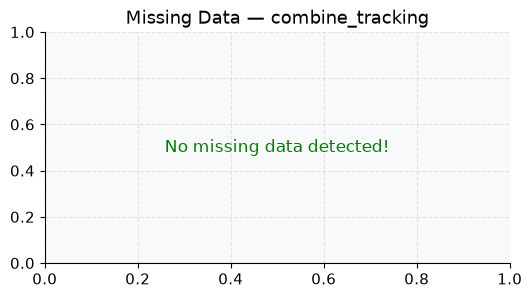

In [9]:
if combine_tracking is not None:
    # Drill type distribution
    print('=== DRILL TYPE DISTRIBUTION ===')
    if 'drill_type' in combine_tracking.columns:
        drill_counts = combine_tracking.groupby('drill_type').agg(
            n_rows=('nfl_id', 'count'),
            n_players=('nfl_id', 'nunique'),
        ).sort_values('n_players', ascending=False)
        display(drill_counts)

    # Drill name distribution
    if 'drill_name' in combine_tracking.columns:
        print('\nTop drill names:')
        display(combine_tracking['drill_name'].value_counts().head(20).to_frame())

    # Attempts per player per drill
    if 'attempt' in combine_tracking.columns and 'drill_type' in combine_tracking.columns:
        attempts_per_player = (
            combine_tracking.groupby(['nfl_id', 'drill_type'])['attempt']
            .nunique()
            .reset_index(name='n_attempts')
        )
        print('\nAttempts per player per drill (distribution):')
        display(attempts_per_player['n_attempts'].describe())
        display(attempts_per_player.groupby('drill_type')['n_attempts'].describe())

    # Frames per attempt
    keys = [c for c in ['nfl_id', 'drill_type', 'attempt'] if c in combine_tracking.columns]
    frames_per_attempt = combine_tracking.groupby(keys).size().reset_index(name='n_frames')
    print('\nFrames per attempt (distribution):')
    display(frames_per_attempt['n_frames'].describe())

    plot_missing_data_heatmap(combine_tracking, title='Missing Data — combine_tracking', filename='missing_combine_tracking.png')

## 6. Player Play — Schema + Basic Stats

In [10]:
player_play = None

try:
    player_play = load_player_play()
    print(f'player_play: {len(player_play):,} rows × {player_play.shape[1]} cols')
    print(f'Memory: {player_play.memory_usage(deep=True).sum() / 1_048_576:.1f} MB')
    print(f'Unique players: {player_play["nfl_id"].nunique()}')
    print(f'Unique games: {player_play["game_id"].nunique() if "game_id" in player_play.columns else "N/A"}')
    display(player_play.head(3))

    # Missing values
    miss_pct = (player_play.isnull().sum() / len(player_play) * 100).sort_values(ascending=False)
    miss_pct = miss_pct[miss_pct > 0]
    print('\nMissing values (%):')
    display(miss_pct.to_frame('missing_pct'))

    if 'position' in player_play.columns:
        print('\nPosition distribution in player_play:')
        display(player_play['position'].value_counts().to_frame())

except FileNotFoundError as e:
    print(f'ERROR: {e}')

WARNING | src.data_loading | player_play: requested columns not in file (skipped): ['position']
INFO | src.data_loading | Loaded player_play: 314,197 rows × 19 cols | 65.5 MB | source: player_play.csv
WARNING | src.data_loading | player_play — columns with missing values:
rec_yards                     307937
yards_after_catch             307937
route_ran                     260889
separation_at_pass_forward    267460
cushion                       210445
expected_yards_after_catch    305221
pressure_allowed              253394
sack_allowed                  253394
time_to_pressure_allowed      309227
quick_pressure                310434
player_get_off                270195
sack                          227362
tackle                        302301
tackle_for_loss               302301
time_to_pressure              310393


player_play: 314,197 rows × 19 cols
Memory: 65.5 MB
Unique players: 497
Unique games: 1001


,game_id,play_id,nfl_id,target,rec_yards,yards_after_catch,route_ran,separation_at_pass_forward,cushion,expected_yards_after_catch,pressure_allowed,sack_allowed,time_to_pressure_allowed,quick_pressure,player_get_off,sack,tackle,tackle_for_loss,time_to_pressure
0,2025111610,2279,57183,False,NaN,NaN,NaN,NaN,NaN,NaN,False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026011701,1626,58248,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025101900,2838,57140,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.906,0.0,NaN,NaN,NaN



Missing values (%):


,missing_pct
quick_pressure,98.802344
time_to_pressure,98.789295
time_to_pressure_allowed,98.418190
yards_after_catch,98.007619
rec_yards,98.007619
expected_yards_after_catch,97.143194
tackle,96.213840
tackle_for_loss,96.213840
player_get_off,85.995411
separation_at_pass_forward,85.124938


## 7. Game Tracking — Schema Only (No Full Load)

In [11]:
from src.config import GAME_TRACKING_FILES

print('=== GAME TRACKING FILES ===')
for season, path in GAME_TRACKING_FILES.items():
    if path.exists():
        size_mb = path.stat().st_size / 1_048_576
        head, dtypes = quick_schema(path, n_rows=3)
        print(f'\ngame_tracking_{season}: {size_mb:.0f} MB | {len(head.columns)} columns')
        display(dtypes)
    else:
        print(f'game_tracking_{season}: FILE NOT FOUND')

=== GAME TRACKING FILES ===

game_tracking_2023: 320 MB | 12 columns


,column,dtype,sample_value
0,game_id,int64,2024010707
1,play_id,int64,570
2,nfl_id,int64,56450
3,time,str,2024-01-07T21:46:07.700
4,x,float64,42.17
5,y,float64,25.29
6,s,int64,0
7,a,int64,0
8,dis,int64,0
9,o,float64,290.97



game_tracking_2024: 685 MB | 12 columns


,column,dtype,sample_value
0,game_id,int64,2024080952
1,play_id,int64,3379
2,nfl_id,int64,57367
3,time,str,2024-08-10T01:30:31.800
4,x,float64,87.09
5,y,float64,22.52
6,s,float64,0.28
7,a,float64,0.11
8,dis,float64,0.03
9,o,float64,98.51



game_tracking_2025: 975 MB | 12 columns


,column,dtype,sample_value
0,game_id,int64,2025090701
1,play_id,int64,290
2,nfl_id,int64,57347
3,time,str,2025-09-07T17:09:39.500
4,x,float64,83.06
5,y,float64,32.06
6,s,float64,0.1
7,a,float64,0.06
8,dis,float64,0.04
9,o,float64,8.0


## 8. Join Validation

In [12]:
if players is not None:
    join_report = validate_player_joins(
        players=players,
        combine_results=combine_results,
        combine_tracking=combine_tracking,
        player_play=player_play,
        career_successes=career_successes,
    )
    print_join_report(join_report)
    
    # Also report how many combine players have NFL outcomes
    if combine_tracking is not None and player_play is not None:
        ct_ids = set(combine_tracking['nfl_id'].dropna().unique())
        pp_ids = set(player_play['nfl_id'].dropna().unique())
        both = ct_ids & pp_ids
        print(f'Players with BOTH combine tracking AND player_play data: {len(both)}')
        print(f'  This is the core analysis population.')
else:
    print('Cannot run join validation — players table not loaded.')


  Player Join Validation Report
  Players in master table:             510
  Players with ALL datasets:           497

  combine_results:
    total players:       510
    in master:           510
    not in master:         0
  combine_tracking:
    total players:       510
    in master:           510
    not in master:         0
  player_play:
    total players:       497
    in master:           497
    not in master:         0
  career_successes:
    total players:       510
    in master:           510
    not in master:         0

Players with BOTH combine tracking AND player_play data: 497
  This is the core analysis population.


## 9. Numeric Summary for All Datasets

In [13]:
import matplotlib.pyplot as plt

for name, df in [
    ('players', players),
    ('combine_results', combine_results),
    ('combine_tracking', combine_tracking),
    ('player_play', player_play),
    ('career_successes', career_successes),
    ('games', games),
]:
    if df is None:
        continue
    print(f'\n{"="*60}')
    print(f'  {name} — Numeric summary')
    print(f'{"="*60}')
    num_cols = df.select_dtypes(include=np.number).columns
    if len(num_cols) > 0:
        display(df[num_cols].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]))
    
    cat_cols = df.select_dtypes(include='object').columns[:5]  # limit to 5
    for col in cat_cols:
        vc = df[col].value_counts()
        print(f'\n  {col} (top 10):')
        display(vc.head(10).to_frame())


  players — Numeric summary


,nfl_id,draft_year,draft_round,draft_pick_within_round,draft_overall_pick
count,510.000000,510.000000,383.000000,383.000000,383.000000
mean,57331.319608,2024.025490,4.101828,19.475196,126.535248
std,979.506689,0.808439,1.913734,11.184497,72.197252
min,55867.000000,2023.000000,1.000000,1.000000,3.000000
10%,55970.900000,2023.000000,2.000000,4.000000,33.200000
25%,56273.500000,2023.000000,2.000000,10.000000,63.500000
50%,57290.000000,2024.000000,4.000000,20.000000,122.000000
75%,58302.750000,2025.000000,6.000000,28.500000,186.000000
90%,58454.100000,2025.000000,7.000000,35.000000,232.800000
max,59278.000000,2025.000000,7.000000,43.000000,257.000000



  display_name (top 10):


C:\Users\Ekaansh\AppData\Local\Temp\ipykernel_3200\324628632.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns[:5]  # limit to 5


,count
display_name,
Anthony Johnson,2
Leonard Taylor,2
Will Anderson,1
Paris Johnson,1
Darnell Wright,1
Peter Skoronski,1
Lukas Van Ness,1
Broderick Jones,1
Will McDonald,1


...

,count
season_type,
REG,816
PRE,147
POST,39



  home_team_abbr (top 10):


,count
home_team_abbr,
PHI,35
KC,34
BUF,34
DET,34
BAL,33
CHI,33
NE,33
DEN,32
SEA,32



  visitor_team_abbr (top 10):


,count
visitor_team_abbr,
HOU,35
GB,34
SF,33
BUF,33
KC,33
LAC,33
WAS,33
PIT,32
DET,31


## 10. Generate data_inventory.md Report

In [14]:
def generate_inventory_report(
    players, combine_results, combine_tracking, player_play,
    career_successes, games, join_report,
) -> str:
    """Generate a markdown inventory report string."""
    from datetime import datetime
    from src.config import ALL_RAW_FILES

    lines = []
    lines.append('# NFL Big Data Bowl 2027 — Data Inventory')
    lines.append(f'\n*Generated: {datetime.now().strftime("%Y-%m-%d %H:%M")}*\n')

    lines.append('## File Sizes')
    lines.append('| File | Status | Size |')
    lines.append('|------|--------|------|')
    for name, path in ALL_RAW_FILES.items():
        if path.exists():
            size_mb = path.stat().st_size / 1_048_576
            lines.append(f'| {name} | ✓ Found | {size_mb:.1f} MB |')
        else:
            lines.append(f'| {name} | ✗ MISSING | — |')

    def df_summary(name, df):
        if df is None:
            return [f'\n## {name}\n\n**NOT LOADED (file missing)**\n']
        rows = [f'\n## {name}\n']
        rows.append(f'- **Rows**: {len(df):,}')
        rows.append(f'- **Columns**: {df.shape[1]}')
        mem_mb = df.memory_usage(deep=True).sum() / 1_048_576
        rows.append(f'- **Memory**: {mem_mb:.1f} MB')
        if 'nfl_id' in df.columns:
            rows.append(f'- **Unique players**: {df["nfl_id"].nunique():,}')
        if 'game_id' in df.columns:
            rows.append(f'- **Unique games**: {df["game_id"].nunique():,}')
        if 'drill_type' in df.columns:
            rows.append(f'- **Unique drill types**: {df["drill_type"].nunique()}')

        miss = df.isnull().sum()
        miss = miss[miss > 0]
        if not miss.empty:
            rows.append('\n**Missing values:**')
            rows.append('| Column | Missing | Pct |')
            rows.append('|--------|---------|-----|')
            for col, n in miss.items():
                rows.append(f'| {col} | {n:,} | {n/len(df)*100:.1f}% |')
        else:
            rows.append('\n**No missing values.**')

        rows.append('\n**Columns and dtypes:**')
        rows.append('| Column | Dtype |')
        rows.append('|--------|-------|')
        for col, dtype in df.dtypes.items():
            rows.append(f'| {col} | {dtype} |')

        return rows

    for name, df in [
        ('players', players), ('combine_results', combine_results),
        ('combine_tracking', combine_tracking), ('player_play', player_play),
        ('career_successes', career_successes), ('games', games),
    ]:
        lines.extend(df_summary(name, df))

    if join_report:
        lines.append('\n## Join Validation')
        lines.append(f'- Master player table: **{join_report.get("n_players_master", "N/A")}** players')
        lines.append(f'- Players with ALL datasets: **{join_report.get("n_players_with_all_datasets", "N/A")}**')
        for prefix in ['combine_results', 'combine_tracking', 'player_play', 'career_successes']:
            n_key = f'{prefix}_n'
            if n_key in join_report:
                lines.append(f'- {prefix}: **{join_report[n_key]}** players ({join_report.get(f"{prefix}_in_master", "?")} in master)')

    return '\n'.join(lines)


# Build and save report
join_report_data = {}
if players is not None:
    join_report_data = validate_player_joins(
        players=players,
        combine_results=combine_results,
        combine_tracking=combine_tracking,
        player_play=player_play,
        career_successes=career_successes,
    )

report_text = generate_inventory_report(
    players, combine_results, combine_tracking, player_play,
    career_successes, games, join_report_data,
)

report_path = REPORTS_DIR / 'data_inventory.md'
report_path.write_text(report_text, encoding='utf-8')
print(f'Report saved to: {report_path}')
print()
print(report_text[:2000], '...(truncated)')

Report saved to: C:\Users\Ekaansh\OneDrive\Desktop\AB\projects\nfl\nfl-bdb-2027\outputs\reports\data_inventory.md

# NFL Big Data Bowl 2027 — Data Inventory

*Generated: 2026-10-08 20:20*

## File Sizes
| File | Status | Size |
|------|--------|------|
| players | ✓ Found | 0.0 MB |
| combine_results | ✓ Found | 0.0 MB |
| combine_tracking | ✓ Found | 79.9 MB |
| player_career_successes | ✓ Found | 0.0 MB |
| player_play | ✓ Found | 140.1 MB |
| games | ✓ Found | 0.0 MB |
| game_tracking_2023 | ✓ Found | 319.9 MB |
| game_tracking_2024 | ✓ Found | 684.7 MB |
| game_tracking_2025 | ✓ Found | 975.2 MB |

## players

- **Rows**: 510
- **Columns**: 10
- **Memory**: 0.1 MB
- **Unique players**: 510

**Missing values:**
| Column | Missing | Pct |
|--------|---------|-----|
| draft_round | 127 | 24.9% |
| draft_pick_within_round | 127 | 24.9% |
| draft_overall_pick | 127 | 24.9% |

**Columns and dtypes:**
| Column | Dtype |
|--------|-------|
| nfl_id | int64 |
| display_name | str |
| draft_